# 1. Introduction

## Project Overview

This project implements a complete machine learning pipeline for multiclass vehicle classification using the Statlog Vehicle Silhouettes dataset from the UCI Machine Learning Repository.

The main objective is to compare different machine learning approaches and evaluate how preprocessing, dimensionality reduction, and ensemble methods affect model performance.

The project includes:

- Data preprocessing and feature scaling
- Correlation analysis and feature selection
- Logistic Regression with hyperparameter tuning
- Principal Component Analysis (PCA)
- Decision Tree classification
- Bagging ensembles
- Random Forest
- ROC curve analysis for multiclass classification
- Learning curve analysis

## Dataset Description

The Statlog Vehicle Silhouettes dataset contains geometric features extracted from vehicle silhouettes. The classification task consists of predicting the vehicle type based on shape-related numerical features.

Vehicle classes:

- bus
- opel
- saab
- van

The dataset contains 18 numerical features describing geometric properties such as compactness, circularity, rectangularity, skewness, kurtosis, and elongation.

# 2. Data Loading

## Data Import

The dataset is distributed across multiple `.dat` files. In this section, all files are loaded and combined into a single pandas DataFrame.

After loading the data, column names are assigned according to the dataset documentation.

In [76]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [2]:
pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
DATA_DIR = Path("/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data")

data_files = sorted(DATA_DIR.glob("*.dat"))

data_files

[PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xaa.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xab.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xac.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xad.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xae.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xaf.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xag.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xah.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xai.dat')]

In [4]:
dfs = []

for file in data_files:
    df_part = pd.read_csv(
        file,
        sep=r"\s+",
        header=None
    )
    
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [5]:
columns = [
    "compactness",
    "circularity",
    "distance_circularity",
    "radius_ratio",
    "pr_axis_aspect_ratio",
    "max_length_aspect_ratio",
    "scatter_ratio",
    "elongatedness",
    "pr_axis_rectangularity",
    "max_length_rectangularity",
    "scaled_variance_major",
    "scaled_variance_minor",
    "scaled_radius_gyration",
    "skewness_major",
    "skewness_minor",
    "kurtosis_major",
    "kurtosis_minor",
    "hollows_ratio",
    "class"
]

df.columns = columns

df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr_axis_aspect_ratio,max_length_aspect_ratio,scatter_ratio,elongatedness,pr_axis_rectangularity,max_length_rectangularity,scaled_variance_major,scaled_variance_minor,scaled_radius_gyration,skewness_major,skewness_minor,kurtosis_major,kurtosis_minor,hollows_ratio,class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   compactness                846 non-null    int64
 1   circularity                846 non-null    int64
 2   distance_circularity       846 non-null    int64
 3   radius_ratio               846 non-null    int64
 4   pr_axis_aspect_ratio       846 non-null    int64
 5   max_length_aspect_ratio    846 non-null    int64
 6   scatter_ratio              846 non-null    int64
 7   elongatedness              846 non-null    int64
 8   pr_axis_rectangularity     846 non-null    int64
 9   max_length_rectangularity  846 non-null    int64
 10  scaled_variance_major      846 non-null    int64
 11  scaled_variance_minor      846 non-null    int64
 12  scaled_radius_gyration     846 non-null    int64
 13  skewness_major             846 non-null    int64
 14  skewness_minor             846 non-nu

In [7]:
df.describe()

,compactness,circularity,distance_circularity,radius_ratio,pr_axis_aspect_ratio,max_length_aspect_ratio,scatter_ratio,elongatedness,pr_axis_rectangularity,max_length_rectangularity,scaled_variance_major,scaled_variance_minor,scaled_radius_gyration,skewness_major,skewness_minor,kurtosis_major,kurtosis_minor,hollows_ratio
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.00000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,93.678487,44.861702,82.088652,168.940898,61.693853,8.567376,168.839243,40.933806,20.582742,147.998818,188.625296,439.911348,174.70331,72.462175,6.377069,12.599291,188.932624,195.632388
std,8.234474,6.169866,15.771533,33.472183,7.888251,4.601217,33.244978,7.811560,2.592138,14.515652,31.394837,176.692614,32.54649,7.486974,4.918353,8.931240,6.163949,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.00000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,146.250000,33.000000,19.000000,137.000000,167.000000,318.250000,149.00000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,178.500000,364.000000,173.00000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.00000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.00000,135.000000,22.000000,41.000000,206.000000,211.000000


In [8]:
df["class"].value_counts()

class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64

## Data Loading Summary

The dataset was successfully loaded from multiple `.dat` files and combined into a single DataFrame.

The final dataset contains 846 observations, 18 numerical features, and one target variable.

There are no missing values in the dataset. The target classes are relatively balanced, which allows us to use accuracy and macro F1-score for model evaluation.

# 3. Exploratory Data Analysis

## Exploratory Data Analysis

In this section, the dataset structure and feature distributions are explored.

The following analyses are performed:

- Dataset shape inspection
- Feature type analysis
- Missing value detection
- Class distribution analysis
- Correlation analysis
- Feature distribution visualization

The purpose of EDA is to better understand the dataset before model training and preprocessing.

In [9]:
df.isnull().sum()

compactness                  0
circularity                  0
distance_circularity         0
radius_ratio                 0
pr_axis_aspect_ratio         0
max_length_aspect_ratio      0
scatter_ratio                0
elongatedness                0
pr_axis_rectangularity       0
max_length_rectangularity    0
scaled_variance_major        0
scaled_variance_minor        0
scaled_radius_gyration       0
skewness_major               0
skewness_minor               0
kurtosis_major               0
kurtosis_minor               0
hollows_ratio                0
class                        0
dtype: int64

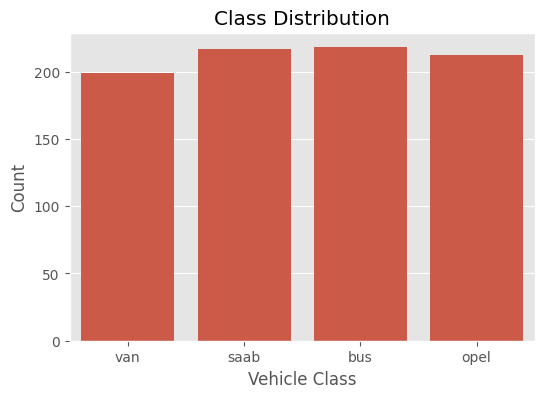

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Class Distribution")
plt.xlabel("Vehicle Class")
plt.ylabel("Count")

plt.show()

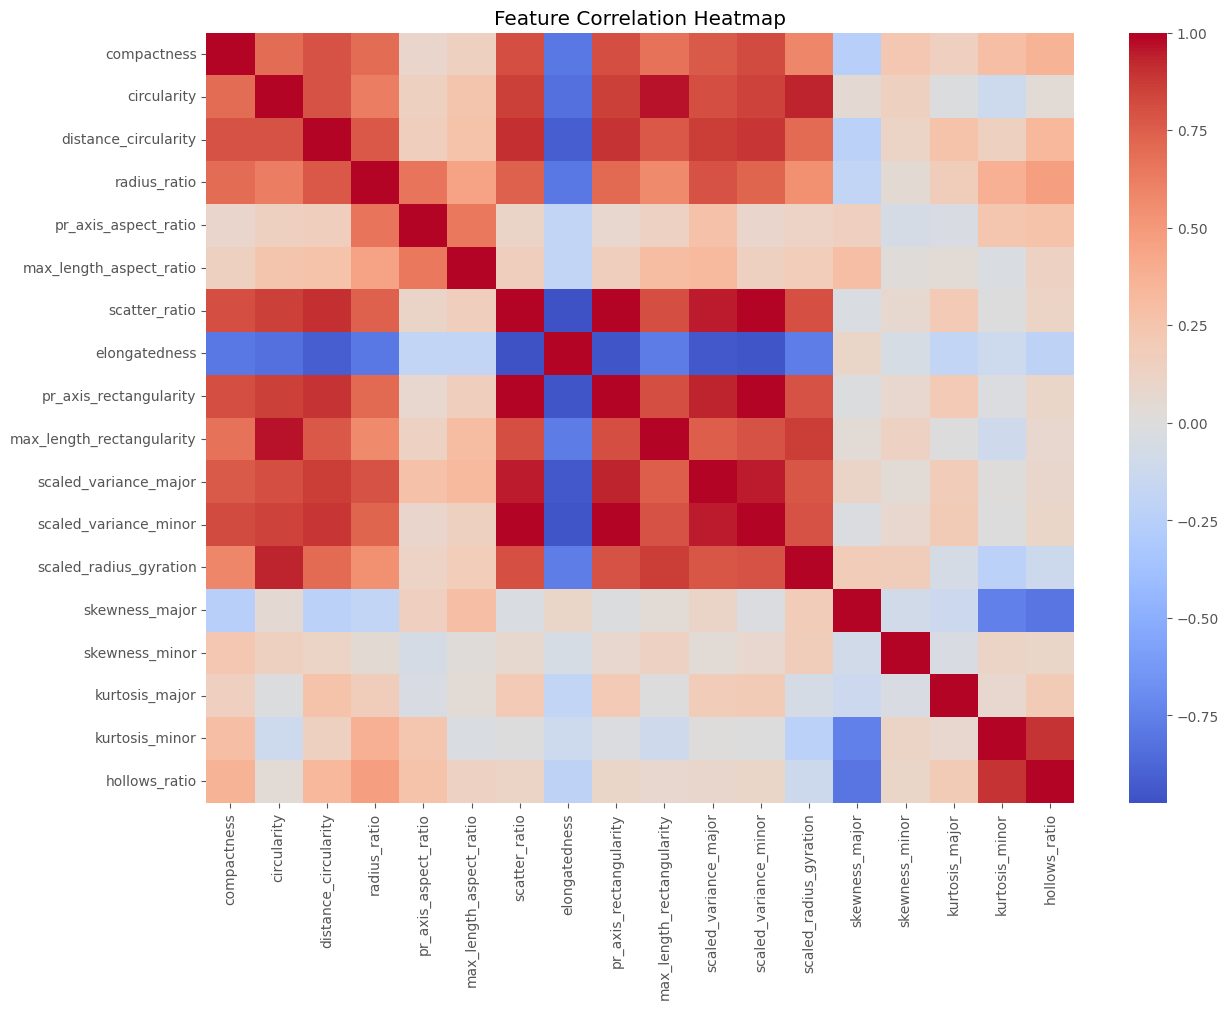

In [11]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.drop(columns="class").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

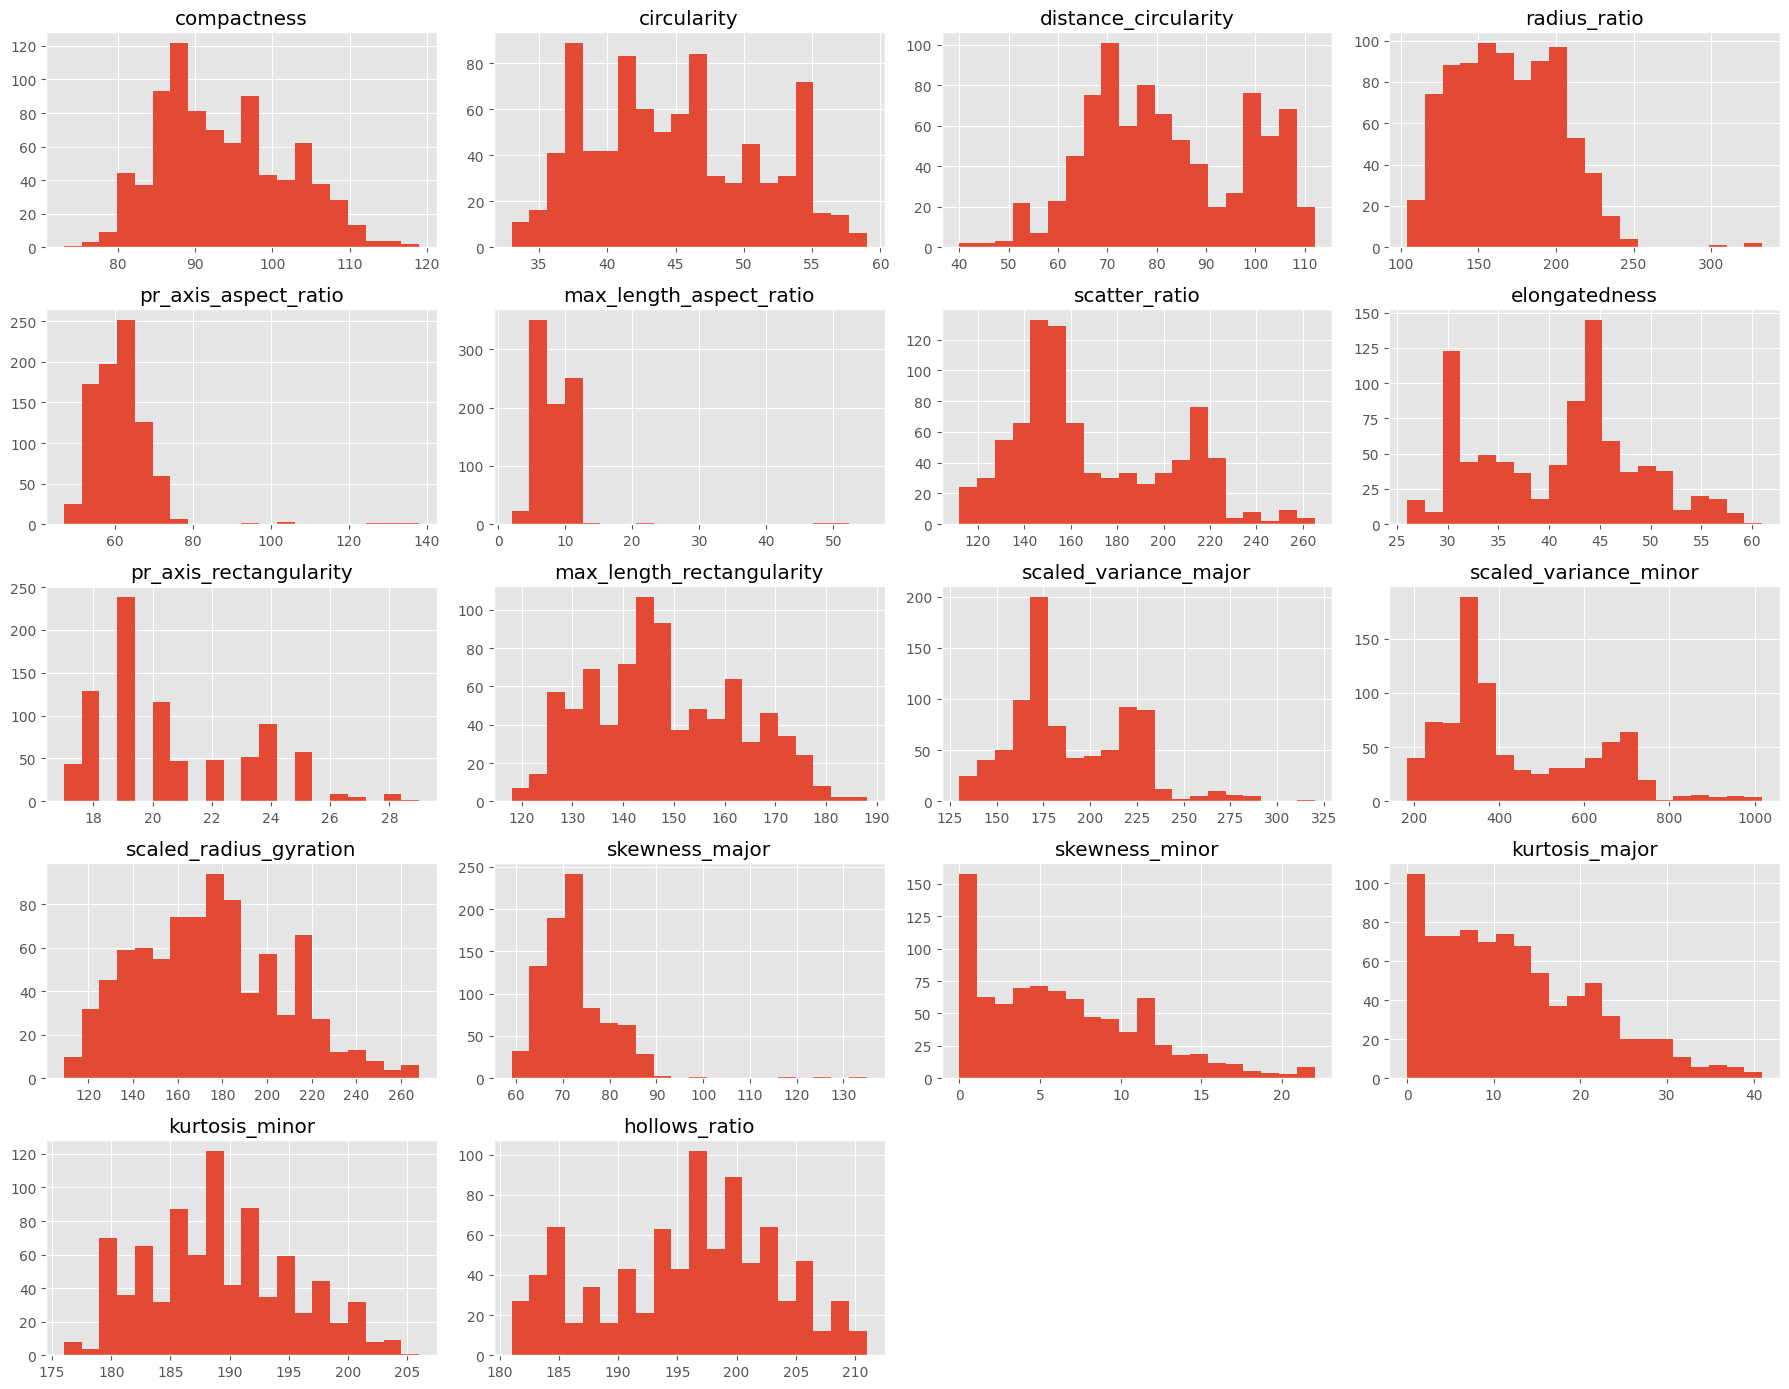

In [12]:
df.drop(columns="class").hist(
    figsize=(18, 14),
    bins=20
)

plt.tight_layout()
plt.show()

## Feature Distribution Analysis

The feature distributions show noticeable differences in scale across variables. Some features have values in relatively small ranges, while others span much larger intervals.

Several variables also exhibit skewed distributions and potential outliers, which is common for geometric and moment-based descriptors.

These observations further justify the use of feature scaling before applying Logistic Regression and PCA.

The multimodal structure observed in some features may indicate class-specific geometric patterns that can be useful for classification.

# 4. Data Preprocessing

## Train-Test Split and Feature Scaling

Before training machine learning models, the dataset is split into training and testing subsets.

Feature scaling is applied using `StandardScaler` because Logistic Regression and PCA are sensitive to differences in feature magnitude.

The preprocessing pipeline also includes correlation analysis and removal of highly correlated features to reduce multicollinearity.

In [13]:
X = df.drop(columns="class")

y = df["class"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (676, 18)
X_test shape: (170, 18)
y_train shape: (676,)
y_test shape: (170,)


In [16]:
corr_matrix = X_train.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]

high_corr_features

['scatter_ratio',
 'elongatedness',
 'pr_axis_rectangularity',
 'max_length_rectangularity',
 'scaled_variance_major',
 'scaled_variance_minor',
 'scaled_radius_gyration']

In [17]:
X_train_reduced = X_train.drop(columns=high_corr_features)
X_test_reduced = X_test.drop(columns=high_corr_features)

X_train_reduced.shape, X_test_reduced.shape

((676, 11), (170, 11))

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reduced)

X_test_scaled = scaler.transform(X_test_reduced)

In [19]:
print("Removed highly correlated features:")
for feature in high_corr_features:
    print("-", feature)

Removed highly correlated features:
- scatter_ratio
- elongatedness
- pr_axis_rectangularity
- max_length_rectangularity
- scaled_variance_major
- scaled_variance_minor
- scaled_radius_gyration


## Feature Selection Results

Several highly correlated features were identified and removed using a correlation threshold of 0.9.

The removed variables were mainly variance-related and geometric descriptors that contained redundant information.

After feature selection, the number of features was reduced from 18 to 11, helping decrease multicollinearity while preserving the majority of the dataset information.

# 5. Logistic Regression

## Logistic Regression Baseline

Logistic Regression is used as the first baseline classification model.

The model is trained on preprocessed data after removing highly correlated features and applying feature scaling. Model performance is evaluated using accuracy and macro F1-score.

## Logistic Regression Overview

Logistic Regression is a linear classification algorithm that estimates class probabilities using a weighted linear combination of input features.

The model computes the following linear score:

$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

where:

- $x_i$ are input features,
- $w_i$ are learned model weights,
- $b$ is the bias term.

For multiclass classification, Logistic Regression uses the softmax function to transform linear scores into normalized class probabilities:

$$
P(y=i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

where:

- $K$ is the number of classes,
- $z_i$ is the score for class $i$.

The model parameters are optimized by minimizing the categorical cross-entropy loss function:

$$
L = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)
$$

where:

- $y_i$ is the true class indicator,
- $\hat{y}_i$ is the predicted probability for class $i$.

In [68]:
logreg_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_baseline.fit(X_train_scaled, y_train)

y_pred_logreg_baseline = logreg_baseline.predict(X_test_scaled)

## Baseline Logistic Regression Evaluation

In [69]:
logreg_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_logreg_baseline
)

logreg_baseline_f1 = f1_score(
    y_test,
    y_pred_logreg_baseline,
    average="macro"
)

print("Baseline Logistic Regression")
print("Accuracy:", round(logreg_baseline_accuracy, 4))
print("Macro F1-score:", round(logreg_baseline_f1, 4))

print(classification_report(
    y_test,
    y_pred_logreg_baseline
))

Baseline Logistic Regression
Accuracy: 0.7647
Macro F1-score: 0.7641
              precision    recall  f1-score   support

         bus       0.87      0.91      0.89        44
        opel       0.61      0.55      0.57        42
        saab       0.66      0.70      0.68        44
         van       0.92      0.90      0.91        40

    accuracy                           0.76       170
   macro avg       0.76      0.77      0.76       170
weighted avg       0.76      0.76      0.76       170



## Logistic Regression Hyperparameter Tuning

To improve model performance, hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.

Different values of the regularization parameter $C$ were evaluated. The parameter $C$ controls the strength of regularization:

- smaller $C$ values increase regularization,
- larger $C$ values reduce regularization.

The best model was selected using the macro F1-score.

In [72]:
logreg_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs"],
}

logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=logreg_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

logreg_grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:",
      logreg_grid_search.best_params_)

print("Best Cross-Validation F1-score:",
      logreg_grid_search.best_score_)

Best Parameters: {'C': 100, 'solver': 'lbfgs'}
Best Cross-Validation F1-score: 0.7379176398396974


In [73]:
best_logreg_model = logreg_grid_search.best_estimator_

## Tuned Logistic Regression Evaluation

In [74]:
y_pred_best_logreg = best_logreg_model.predict(
    X_test_scaled
)

tuned_logreg_accuracy = accuracy_score(
    y_test,
    y_pred_best_logreg
)

tuned_logreg_f1 = f1_score(
    y_test,
    y_pred_best_logreg,
    average="macro"
)

print("Tuned Logistic Regression")
print("Accuracy:", round(tuned_logreg_accuracy, 4))
print("Macro F1-score:", round(tuned_logreg_f1, 4))

print(classification_report(
    y_test,
    y_pred_best_logreg
))

Tuned Logistic Regression
Accuracy: 0.7882
Macro F1-score: 0.7894
              precision    recall  f1-score   support

         bus       0.95      0.89      0.92        44
        opel       0.65      0.62      0.63        42
        saab       0.68      0.73      0.70        44
         van       0.88      0.93      0.90        40

    accuracy                           0.79       170
   macro avg       0.79      0.79      0.79       170
weighted avg       0.79      0.79      0.79       170



## ROC Curve for Logistic Regression

ROC curves were constructed using the one-vs-rest strategy for multiclass classification.

The ROC curve illustrates the relationship between the true positive rate and false positive rate for different classification thresholds.

In [77]:
classes = np.unique(y_train)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_score = best_logreg_model.predict_proba(
    X_test_scaled
)

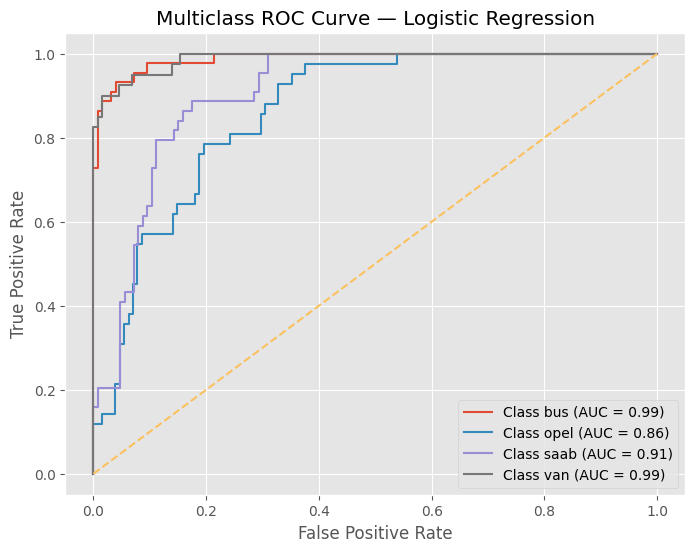

In [78]:
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve — Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the model performs very well on the `bus` and `van` classes, with most samples classified correctly.

The largest source of error occurs between the `opel` and `saab` classes. Many `opel` samples are predicted as `saab`, and vice versa.

This result is consistent with the dataset documentation, which states that the two car classes are more difficult to distinguish because of their similar geometric characteristics.

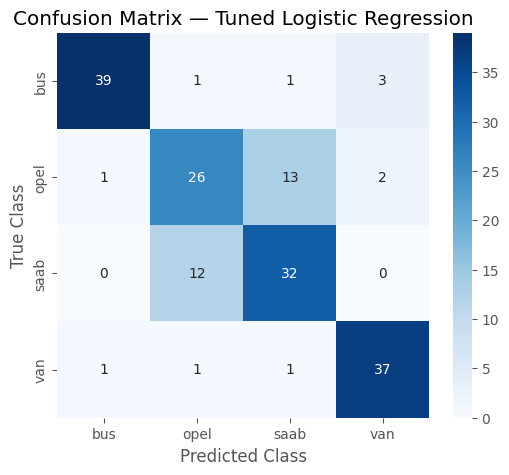

In [79]:
conf_matrix = confusion_matrix(
    y_test,
    y_pred_best_logreg
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_logreg_model.classes_,
    yticklabels=best_logreg_model.classes_
)

plt.title("Confusion Matrix — Tuned Logistic Regression")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

## Logistic Regression Analysis

The baseline Logistic Regression model achieved an accuracy of approximately 0.765 and a macro F1-score of approximately 0.764.

After hyperparameter tuning with GridSearchCV, the best model used the regularization parameter:

$$
C = 100
$$

The tuned model improved the classification performance and achieved:

- Accuracy: approximately 0.788
- Macro F1-score: approximately 0.789

The confusion matrix and classification report show that the model performs very well on the `bus` and `van` classes. These classes achieved the highest precision and recall values.

The most difficult classes remain `opel` and `saab`. Their F1-scores are lower because the geometric characteristics of these vehicles are more similar, making them harder to distinguish.

The ROC curves also confirm strong classification performance for the `bus` and `van` classes, both achieving AUC values close to 0.99. The `saab` class achieved an AUC of approximately 0.91, while the `opel` class achieved the lowest AUC value of approximately 0.86.

Overall, Logistic Regression demonstrated strong and stable multiclass classification performance after feature preprocessing and hyperparameter optimization.

# 6. PCA

## Principal Component Analysis

Principal Component Analysis is used to reduce feature dimensionality and analyze how much variance is explained by each principal component.

PCA is fitted only on the training data to avoid data leakage. The test data is transformed using the PCA transformation learned from the training data.

## Principal Component Analysis Theory

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original correlated features into a new orthogonal feature space.

PCA can be interpreted as constructing a new orthonormal basis in the feature space, where each basis vector corresponds to a principal component.

The principal components are linear combinations of the original variables and are ordered according to the amount of variance they explain.

The first principal component captures the direction of maximum variance in the data. Each subsequent component captures the maximum remaining variance while remaining orthogonal to the previous components.

Mathematically, each principal component can be represented as:

$$
PC_i = a_{i1}x_1 + a_{i2}x_2 + \dots + a_{in}x_n
$$

where:

- $x_1, x_2, \dots, x_n$ are the original features,
- $a_{ij}$ are component coefficients.

PCA is based on the eigendecomposition of the covariance matrix of the standardized data.

The eigenvectors define the directions of the principal components, while the eigenvalues determine how much variance is explained by each component.

The explained variance ratio for component $i$ is computed as:

$$
\frac{\lambda_i}{\sum_{j=1}^{n}\lambda_j}
$$

where:

- $\lambda_i$ is the eigenvalue of the $i$-th component,
- the denominator is the total variance across all components.

PCA reduces dimensionality by preserving only the components that explain most of the total variance.

In [27]:
pca_full = PCA()

pca_full.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [28]:
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

cumulative_explained_variance

array([0.36154589, 0.58413823, 0.73567059, 0.83594943, 0.91414536,
       0.94773191, 0.97187717, 0.98469686, 0.99319848, 0.99755811,
       1.        ])

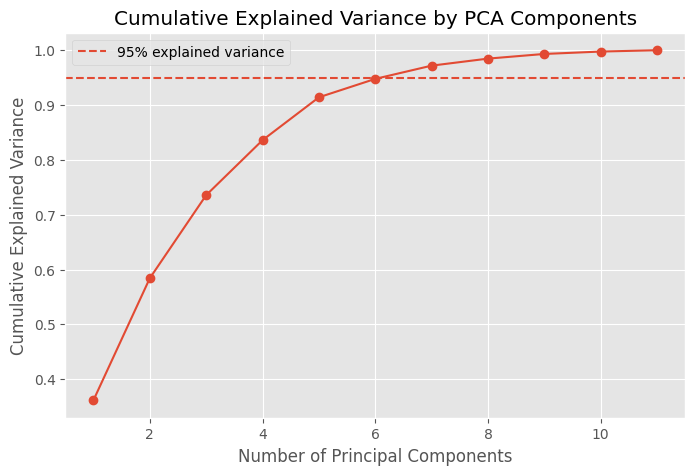

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% explained variance"
)

plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
n_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1

n_components_95

np.int64(7)

In [31]:
pca = PCA(n_components=n_components_95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca.shape, X_test_pca.shape

((676, 7), (170, 7))

## Logistic Regression on PCA Features

After dimensionality reduction, Logistic Regression is trained again using the PCA-transformed feature space.

This allows comparison between:

- the original feature representation,
- the reduced PCA representation.

The goal is to evaluate whether dimensionality reduction improves generalization while preserving classification performance.

In [32]:
logreg_pca = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_pca.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
y_pred_logreg_pca = logreg_pca.predict(X_test_pca)

In [34]:
logreg_pca_accuracy = accuracy_score(
    y_test,
    y_pred_logreg_pca
)

logreg_pca_f1 = f1_score(
    y_test,
    y_pred_logreg_pca,
    average="macro"
)

print("Logistic Regression with PCA")
print("Accuracy:", round(logreg_pca_accuracy, 4))
print("Macro F1-score:", round(logreg_pca_f1, 4))

Logistic Regression with PCA
Accuracy: 0.5824
Macro F1-score: 0.58


In [35]:
print(classification_report(
    y_test,
    y_pred_logreg_pca
))

              precision    recall  f1-score   support

         bus       0.66      0.75      0.70        44
        opel       0.42      0.40      0.41        42
        saab       0.55      0.55      0.55        44
         van       0.69      0.62      0.66        40

    accuracy                           0.58       170
   macro avg       0.58      0.58      0.58       170
weighted avg       0.58      0.58      0.58       170



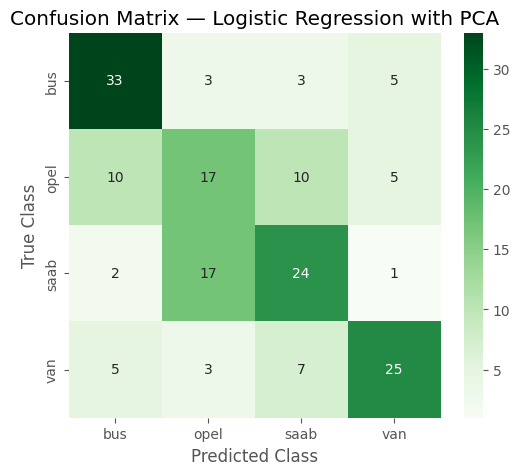

In [36]:
conf_matrix_pca = confusion_matrix(
    y_test,
    y_pred_logreg_pca
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix_pca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=logreg_pca.classes_,
    yticklabels=logreg_pca.classes_
)

plt.title("Confusion Matrix — Logistic Regression with PCA")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

## PCA Model Evaluation

The Logistic Regression model trained on PCA-transformed features demonstrates lower performance compared to the baseline model trained on the original feature space.

Although PCA preserved approximately 95% of the total variance, the classification metrics decreased significantly:

- baseline macro F1-score: 0.7641
- PCA macro F1-score: 0.58

This result indicates that the directions with the highest variance are not necessarily the most informative for class separation.

Since PCA is an unsupervised dimensionality reduction method, it does not use class labels during transformation and may remove information important for classification.

The confusion matrix also shows increased confusion between vehicle classes after dimensionality reduction.

# 7. Decision Tree

## Decision Tree Classification

Decision Trees are non-linear machine learning models that recursively partition the feature space into regions corresponding to different classes.

Unlike Logistic Regression, Decision Trees can capture complex non-linear relationships between features without requiring feature scaling.

## Decision Tree Theory

A Decision Tree constructs a hierarchical set of decision rules by recursively splitting the dataset according to feature thresholds.

At each node, the algorithm selects the split that maximizes class separation and reduces node impurity.

One of the most common impurity measures is the Gini impurity:

$$
G = 1 - \sum_{i=1}^{K} p_i^2
$$

where:

- $K$ is the number of classes,
- $p_i$ is the probability of class $i$ within the node.

The Gini impurity can be interpreted as the probability of assigning different classes to two randomly selected objects from the same node.

Lower impurity corresponds to more homogeneous nodes, while higher impurity indicates stronger mixing of classes.

The tree continues splitting until stopping criteria are reached, such as maximum depth or minimum number of samples per node.

In [38]:
tree_baseline = DecisionTreeClassifier(
    random_state=42
)

tree_baseline.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Feature Scaling and Decision Trees

Feature scaling is not required for Decision Trees because tree-based models split data using threshold comparisons rather than distance-based calculations.

In [39]:
y_pred_tree_baseline = tree_baseline.predict(X_test)

In [40]:
tree_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_tree_baseline
)

tree_baseline_f1 = f1_score(
    y_test,
    y_pred_tree_baseline,
    average="macro"
)

print("Baseline Decision Tree")
print("Accuracy:", round(tree_baseline_accuracy, 4))
print("Macro F1-score:", round(tree_baseline_f1, 4))

Baseline Decision Tree
Accuracy: 0.7176
Macro F1-score: 0.7229


In [41]:
print(classification_report(
    y_test,
    y_pred_tree_baseline
))

              precision    recall  f1-score   support

         bus       0.89      0.95      0.92        44
        opel       0.52      0.57      0.55        42
        saab       0.56      0.57      0.56        44
         van       0.97      0.78      0.86        40

    accuracy                           0.72       170
   macro avg       0.73      0.72      0.72       170
weighted avg       0.73      0.72      0.72       170



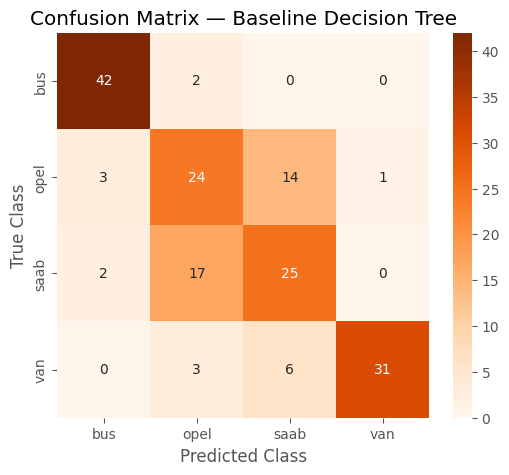

In [42]:
conf_matrix_tree = confusion_matrix(
    y_test,
    y_pred_tree_baseline
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix_tree,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=tree_baseline.classes_,
    yticklabels=tree_baseline.classes_
)

plt.title("Confusion Matrix — Baseline Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

## Baseline Decision Tree Evaluation

The baseline Decision Tree achieves slightly lower performance than Logistic Regression.

The model performs very well on the `bus` and `van` classes, while significant confusion remains between the `opel` and `saab` classes.

This suggests that the dataset is relatively well-separated using linear decision boundaries, limiting the advantage of non-linear tree-based models.

Since the baseline tree is trained without depth ограничения, the model may also suffer from overfitting.

## Decision Tree Hyperparameter Tuning

The baseline Decision Tree was trained without depth ограничения, which may lead to overfitting.

To improve generalization, the optimal tree depth is selected using `GridSearchCV` with cross-validation.

The main hyperparameter being tuned is `max_depth`, which controls how many consecutive splits the tree can make.

In [43]:
tree_param_grid = {
    "max_depth": range(1, 21)
}

In [46]:
tree_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

tree_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

In [47]:
print("Best Parameters:")
print(tree_grid_search.best_params_)

print("Best Cross-Validation Macro F1:")
print(round(tree_grid_search.best_score_, 4))

Best Parameters:
{'max_depth': 18}
Best Cross-Validation Macro F1:
0.715


In [48]:
best_tree = tree_grid_search.best_estimator_

In [49]:
y_pred_best_tree = best_tree.predict(X_test)

In [50]:
best_tree_accuracy = accuracy_score(y_test, y_pred_best_tree)
best_tree_f1 = f1_score(y_test, y_pred_best_tree, average="macro")

print("Tuned Decision Tree")
print("Accuracy:", round(best_tree_accuracy, 4))
print("Macro F1-score:", round(best_tree_f1, 4))

Tuned Decision Tree
Accuracy: 0.7176
Macro F1-score: 0.7229


In [ ]:
print(classification_report(y_test, y_pred_best_tree))

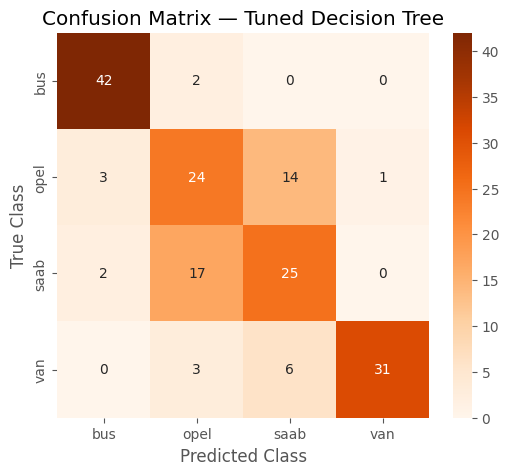

In [51]:
conf_matrix_best_tree = confusion_matrix(y_test, y_pred_best_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix_best_tree,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=best_tree.classes_,
    yticklabels=best_tree.classes_
)

plt.title("Confusion Matrix — Tuned Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

## Tuned Decision Tree Evaluation

GridSearchCV selected `max_depth = 18` as the best tree depth based on macro F1-score during cross-validation.

The tuned Decision Tree achieved the same test performance as the baseline Decision Tree:

- Accuracy: 0.7176
- Macro F1-score: 0.7229

This indicates that the unrestricted baseline tree already learned a structure close to the optimal depth found by cross-validation.

The model still performs well on the `bus` and `van` classes, while the main source of errors remains confusion between `opel` and `saab`.

# 8. Bagging

## Bagging Ensembles

Bagging ensembles are applied to improve model stability and reduce variance.

Two ensemble configurations are investigated:

- Bagging with Logistic Regression
- Bagging with Decision Trees

The influence of the number of estimators on model performance is analyzed using:

- Accuracy curves
- F1-score curves

The goal is to determine whether ensemble methods improve classification performance compared to single models.

In [53]:
n_estimators_range = [1, 5, 10, 20, 30, 50, 75, 100]

bagging_results = []

for n_estimators in n_estimators_range:
    bagging_logreg = BaggingClassifier(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1
    )
    
    bagging_logreg.fit(X_train_scaled, y_train)
    y_pred = bagging_logreg.predict(X_test_scaled)
    
    bagging_results.append({
        "model": "Bagging Logistic Regression",
        "n_estimators": n_estimators,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

for n_estimators in n_estimators_range:
    bagging_tree = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=tree_grid_search.best_params_["max_depth"],
            random_state=42
        ),
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1
    )
    
    bagging_tree.fit(X_train, y_train)
    y_pred = bagging_tree.predict(X_test)
    
    bagging_results.append({
        "model": "Bagging Decision Tree",
        "n_estimators": n_estimators,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

bagging_results_df = pd.DataFrame(bagging_results)
bagging_results_df

,model,n_estimators,accuracy,f1_macro
0,Bagging Logistic Regression,1,0.747059,0.749265
1,Bagging Logistic Regression,5,0.747059,0.746436
2,Bagging Logistic Regression,10,0.758824,0.757737
3,Bagging Logistic Regression,20,0.764706,0.763194
4,Bagging Logistic Regression,30,0.764706,0.763194
5,Bagging Logistic Regression,50,0.758824,0.757737
6,Bagging Logistic Regression,75,0.764706,0.763194
7,Bagging Logistic Regression,100,0.758824,0.757737
8,Bagging Decision Tree,1,0.735294,0.734560
9,Bagging Decision Tree,5,0.717647,0.716762


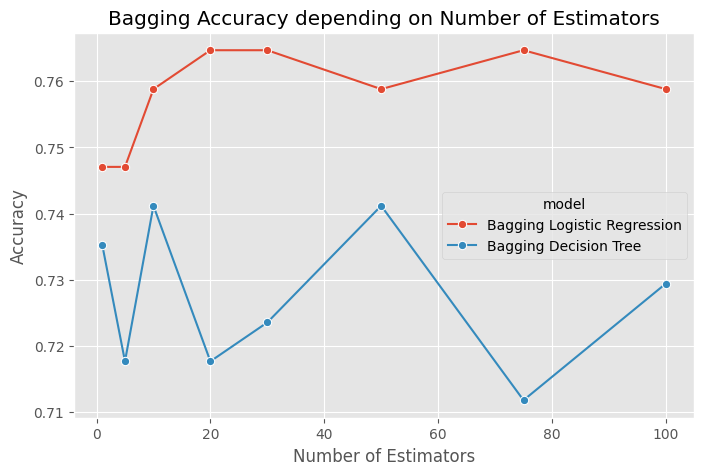

In [54]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=bagging_results_df,
    x="n_estimators",
    y="accuracy",
    hue="model",
    marker="o"
)

plt.title("Bagging Accuracy depending on Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [56]:
best_bagging_models = bagging_results_df.loc[
    bagging_results_df.groupby("model")["f1_macro"].idxmax()
]

best_bagging_models

,model,n_estimators,accuracy,f1_macro
10,Bagging Decision Tree,10,0.741176,0.739189
3,Bagging Logistic Regression,20,0.764706,0.763194


## Bagging Results Analysis

Bagging ensembles were evaluated for Logistic Regression and Decision Tree classifiers using different numbers of estimators.

For Logistic Regression, bagging slightly improved the performance compared to a single model. The best results were achieved with approximately 20–75 estimators, where the accuracy reached about 0.765 and macro F1-score reached about 0.763. After this point, the metrics became stable, indicating that increasing the number of estimators further does not provide significant improvement.

For Decision Trees, bagging produced less stable results. Although ensemble methods are generally effective for reducing variance in decision trees, the performance fluctuated depending on the number of estimators. The best result was achieved with 10 estimators, where the accuracy reached about 0.741 and macro F1-score reached about 0.739.

Overall, Bagging with Logistic Regression demonstrated better and more stable performance on this dataset than Bagging with Decision Trees. The optimal number of estimators was selected based on the highest macro F1-score while also considering computational efficiency.

# 9. Random Forest

## Random Forest Classification

Random Forest is trained as an advanced ensemble learning method based on multiple decision trees.

The influence of the number of trees on model quality is analyzed.

Model evaluation includes:

- Accuracy
- F1-score

Performance trends are visualized to identify the optimal number of trees and evaluate ensemble effectiveness.

In [58]:
n_estimators_range = [1, 5, 10, 20, 30, 50, 75, 100]

rf_results = []

for n_estimators in n_estimators_range:
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=tree_grid_search.best_params_["max_depth"],
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    
    y_pred = rf_model.predict(X_test)
    
    rf_results.append({
        "n_estimators": n_estimators,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

rf_results_df = pd.DataFrame(rf_results)

rf_results_df

,n_estimators,accuracy,f1_macro
0,1,0.652941,0.661063
1,5,0.682353,0.680759
2,10,0.676471,0.667446
3,20,0.700000,0.693689
4,30,0.735294,0.726284
5,50,0.717647,0.706981
6,75,0.711765,0.704421
7,100,0.723529,0.717948


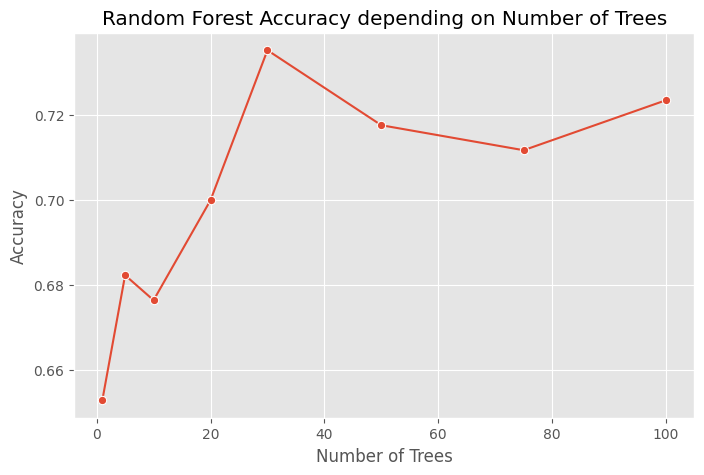

In [59]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=rf_results_df,
    x="n_estimators",
    y="accuracy",
    marker="o"
)

plt.title("Random Forest Accuracy depending on Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

In [61]:
best_rf_model = rf_results_df.loc[
    rf_results_df["f1_macro"].idxmax()
]

best_rf_model

n_estimators    30.000000
accuracy         0.735294
f1_macro         0.726284
Name: 4, dtype: float64

# 10. Learning Curves

## Learning Curve Analysis

Learning curves are used to analyze how model performance changes as the size of the training dataset increases.

The training data is divided into multiple subsets of increasing size.

For each subset, models are trained and evaluated using:

- Accuracy
- F1-score

This analysis helps determine:

- Whether the models benefit from additional data
- Whether underfitting or overfitting is present
- How model stability changes with dataset size

In [67]:
best_logreg_model = logreg_grid_search.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_logreg_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

NameError: name 'logreg_grid_search' is not defined

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_scores_mean, marker="o", label="Train F1")
plt.plot(train_sizes, test_scores_mean, marker="o", label="Validation F1")

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1-score")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
train_sizes_acc, train_scores_acc, test_scores_acc = learning_curve(
    estimator=best_logreg_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_acc_mean = train_scores_acc.mean(axis=1)
test_scores_acc_mean = test_scores_acc.mean(axis=1)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes_acc, train_scores_acc_mean, marker="o", label="Train Accuracy")
plt.plot(train_sizes_acc, test_scores_acc_mean, marker="o", label="Validation Accuracy")

plt.title("Learning Curve Accuracy - Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_rf_classifier = RandomForestClassifier(
    n_estimators=int(best_rf_model["n_estimators"]),
    max_depth=tree_grid_search.best_params_["max_depth"],
    random_state=42,
    n_jobs=-1
)

In [ ]:
train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    estimator=best_rf_classifier,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_rf_mean = train_scores_rf.mean(axis=1)
test_scores_rf_mean = test_scores_rf.mean(axis=1)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes_rf, train_scores_rf_mean, marker="o", label="Train F1")
plt.plot(train_sizes_rf, test_scores_rf_mean, marker="o", label="Validation F1")

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1-score")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
train_sizes_rf_acc, train_scores_rf_acc, test_scores_rf_acc = learning_curve(
    estimator=best_rf_classifier,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_rf_acc_mean = train_scores_rf_acc.mean(axis=1)
test_scores_rf_acc_mean = test_scores_rf_acc.mean(axis=1)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes_rf_acc, train_scores_rf_acc_mean, marker="o", label="Train Accuracy")
plt.plot(train_sizes_rf_acc, test_scores_rf_acc_mean, marker="o", label="Validation Accuracy")

plt.title("Learning Curve Accuracy - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# 11. Final Conclusions

## Final Conclusions

In this section, the performance of all trained models is summarized and compared.

The analysis focuses on:

- The impact of preprocessing
- The effectiveness of PCA
- The benefits of ensemble learning
- Model stability and generalization performance

The best-performing model is identified based on evaluation metrics and overall behavior across experiments.